In [4]:
import cv2
import time
import matplotlib.pyplot as plt

class FeatureExtractor():
  def __init__(self, feature_type, n_features=1000):
      self.n_features = n_features
      self.extractor = self.create_extractor(feature_type)

  def create_extractor(self, feature_type):
    if feature_type == "SIFT":
      return cv2.SIFT_create(nfeatures=self.n_features)
    elif feature_type == "ORB":
      return cv2.ORB_create(nfeatures=self.n_features)
    elif feature_type == "KAZE":    #KAZE and AKAZE don't have a built-in nfeatures method
      return cv2.KAZE_create()
    elif feature_type == "AKAZE":
      return cv2.AKAZE_create()
    else:
      raise ValueError(f"Unsuported feature type: {feature_type}")

  def extract(self, frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    start_time = time.time()
    keypoints, descriptors = self.extractor.detectAndCompute(gray, None)
    end_time = time.time()

    execution_time = (end_time - start_time) * 1000  # conversion to ms

    return keypoints, descriptors, execution_time


In [10]:
class FeatureMatcher:
    def __init__(self, feature_type):
      self.match_metric = self.get_match_metric(feature_type)
      self.bf_matcher = cv2.BFMatcher(self.match_metric, crossCheck=False)

    def get_match_metric(self, feature_type):
      if feature_type in ["ORB","AKAZE"]:
        return cv2.NORM_HAMMING
      elif feature_type in ["SIFT","KAZE"]:
        return cv2.NORM_L2
      else:
        raise(ValueError(f"Unsuported feature type: {feature_type}"))

    def match(self, des1, des2, ratio=0.75):
      matches = self.bf_matcher.knnMatch(des1,des2,k=2)
      good = []
      for m,n in matches:
        if m.distance < ratio*n.distance:
          good.append([m])
      return good

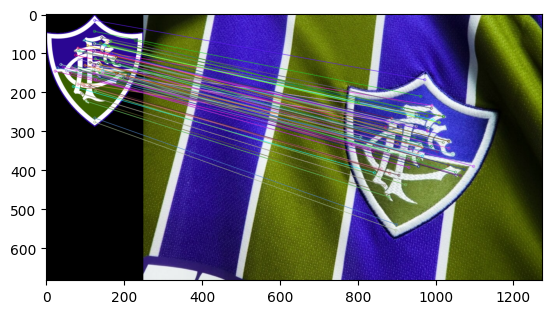

In [15]:
def main():
  img1 = cv2.imread('flu1.png')
  img2 = cv2.imread('flu2.jpg')
  feature_types = ["SIFT", "ORB", "KAZE", "AKAZE"]

  extractor = FeatureExtractor(feature_types[0],1000)
  matcher = FeatureMatcher(feature_types[0])

  kp1,d1,t1 = extractor.extract(img1)
  kp2,d2,t2 = extractor.extract(img2)

  good = matcher.match(d1,d2,0.75)
  img3 = cv2.drawMatchesKnn(img1,kp1,img2,kp2,good,None,flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
  plt.imshow(img3),plt.show()

if __name__ == "__main__":
  main()